# 03 Model Comparison Notebook

This notebook compares the outputs from the two evaluation notebooks. It does not load the models again; it reads the exported metrics and predictions.

In [10]:
!pip -q install pandas matplotlib seaborn scikit-learn

In [11]:
import zipfile
import os

content_dir = "/content"

# Iterate over all files in the /content directory
for item in os.listdir(content_dir):
    item_path = os.path.join(content_dir, item)
    if os.path.isfile(item_path) and item.endswith(".zip"):
        try:
            # Create a directory named after the zip file (without .zip extension)
            zip_name = os.path.splitext(item)[0]
            extract_dir = os.path.join(content_dir, zip_name)
            os.makedirs(extract_dir, exist_ok=True)

            with zipfile.ZipFile(item_path, 'r') as zip_ref:
                zip_ref.extractall(extract_dir)
            print(f"Extracted {item} to {extract_dir}")
        except zipfile.BadZipFile:
            print(f"Skipping {item}: Not a valid zip file.")
        except Exception as e:
            print(f"An error occurred while extracting {item}: {e}")


Extracted phase2_outputs.zip to /content/phase2_outputs
Extracted phase1_outputs.zip to /content/phase1_outputs


In [12]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

P1 = Path("/content/phase1_outputs")
P2 = Path("/content/phase2_outputs")

assert P1.exists(), "phase1_outputs folder not found. Run notebook 1 first."
assert P2.exists(), "phase2_outputs folder not found. Run notebook 2 first."

In [13]:
def get_p2_path(filename: str) -> Path:
    """
    Checks for a file in the P2 base_path or a subdirectory named after P2's name.
    """
    direct_path = P2 / filename
    if direct_path.exists():
        return direct_path

    # If not found directly, try looking in a subdirectory named after the P2 path
    nested_path = P2 / P2.name / filename
    if nested_path.exists():
        return nested_path

    raise FileNotFoundError(f"Neither {direct_path} nor {nested_path} found for {filename}")

with open(P1 / "metrics.json") as f:
    m1 = json.load(f)
with open(get_p2_path("metrics.json")) as f:
    m2 = json.load(f)

d1 = pd.read_csv(P1 / "predictions.csv")
d2 = pd.read_csv(get_p2_path("predictions.csv"))
b1 = pd.read_csv(P1 / "age_bucket_accuracy.csv")
b2 = pd.read_csv(get_p2_path("age_bucket_accuracy.csv"))
r1 = pd.read_csv(P1 / "robustness.csv")
r2 = pd.read_csv(get_p2_path("robustness.csv"))

summary = pd.DataFrame([
    {"Model": "Phase 1 / Distillation", **m1},
    {"Model": "Phase 2 / Strong Regularization", **m2},
])
summary

,Model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,log_loss,avg_batch_time_sec,ms_per_image,model_file_mb,prediction_entropy,confidence_mean
0,Phase 1 / Distillation,0.686,0.687115,0.718750,0.631373,0.672234,0.735226,0.692923,0.168156,2.690492,43.23,0.417028,0.820552
1,Phase 2 / Strong Regularization,0.663,0.664286,0.697039,0.600000,0.644889,0.740968,0.640654,0.214359,3.429743,43.24,0.471063,0.782599


In [14]:
# Core comparison table
cols = ["accuracy", "balanced_accuracy", "precision", "recall", "f1", "roc_auc", "log_loss", "ms_per_image", "prediction_entropy", "confidence_mean"]
comp = summary[["Model"] + cols].copy()
comp

,Model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,log_loss,ms_per_image,prediction_entropy,confidence_mean
0,Phase 1 / Distillation,0.686,0.687115,0.718750,0.631373,0.672234,0.735226,0.692923,2.690492,0.417028,0.820552
1,Phase 2 / Strong Regularization,0.663,0.664286,0.697039,0.600000,0.644889,0.740968,0.640654,3.429743,0.471063,0.782599


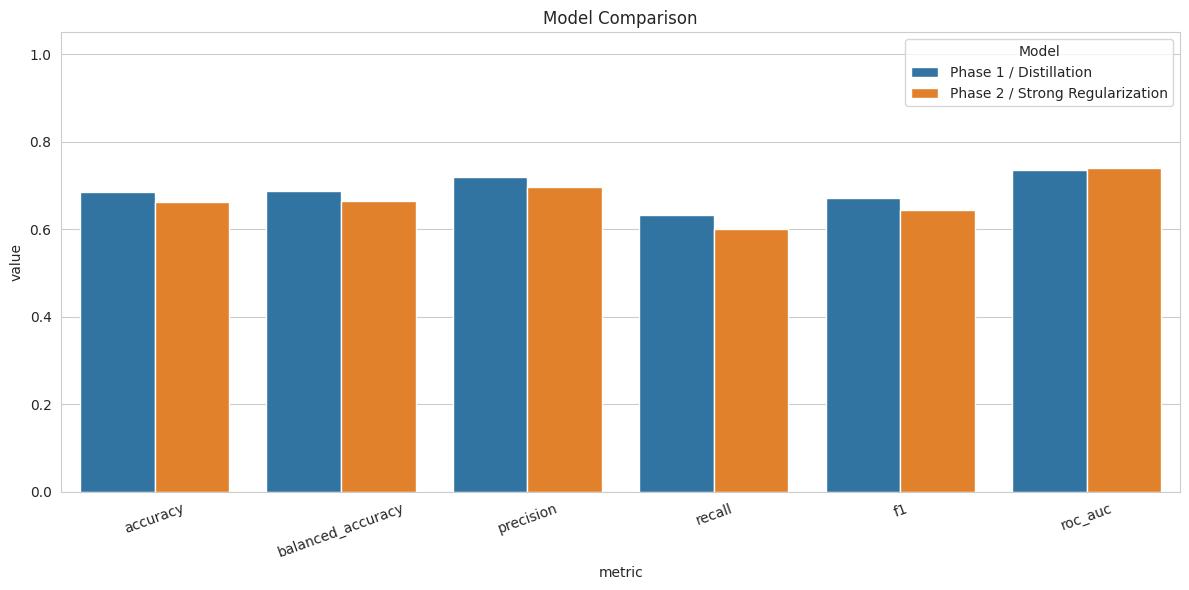

In [15]:
# Bar plot comparison
plot_cols = ["accuracy", "balanced_accuracy", "precision", "recall", "f1", "roc_auc"]
plot_df = comp.melt(id_vars="Model", value_vars=plot_cols, var_name="metric", value_name="value")

plt.figure(figsize=(12,6))
sns.barplot(data=plot_df, x="metric", y="value", hue="Model")
plt.ylim(0, 1.05)
plt.title("Model Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

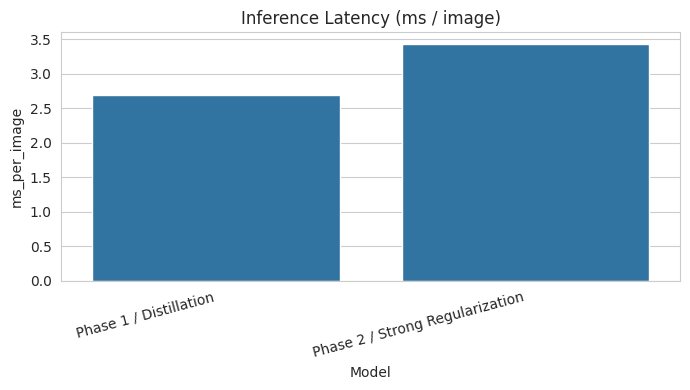

In [16]:
# Latency comparison
lat = summary[["Model", "ms_per_image"]]
plt.figure(figsize=(7,4))
sns.barplot(data=lat, x="Model", y="ms_per_image")
plt.xticks(rotation=15, ha="right")
plt.title("Inference Latency (ms / image)")
plt.tight_layout()
plt.show()

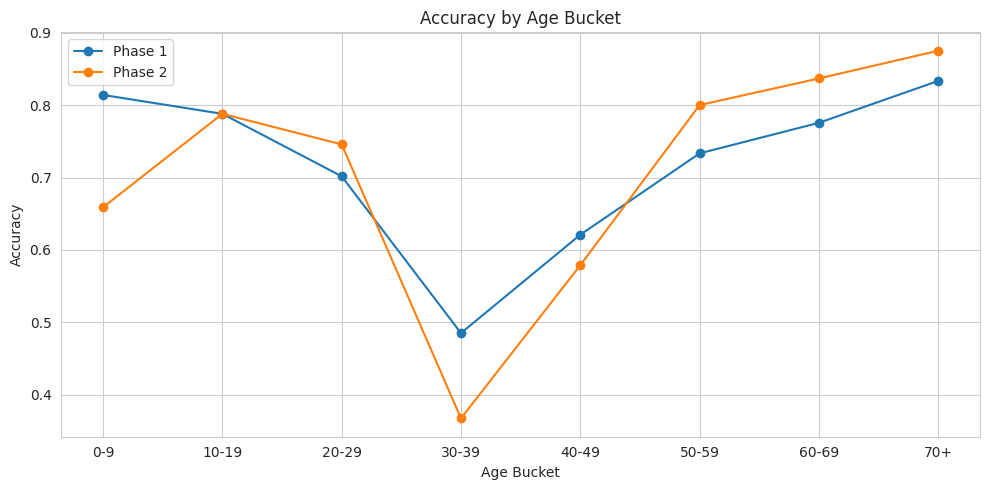

,bucket,accuracy_phase1,avg_confidence_phase1,count_phase1,accuracy_phase2,avg_confidence_phase2,count_phase2
0,0-9,0.813953,0.789226,129.0,0.658915,0.753568,129.0
1,10-19,0.787879,0.812318,66.0,0.787879,0.791605,66.0
2,20-29,0.701695,0.821465,295.0,0.745763,0.772518,295.0
3,30-39,0.485294,0.809417,204.0,0.367647,0.766983,204.0
4,40-49,0.621053,0.828852,95.0,0.578947,0.793419,95.0
5,50-59,0.733333,0.851572,90.0,0.800000,0.829866,90.0
6,60-69,0.775510,0.839597,49.0,0.836735,0.804336,49.0
7,70+,0.833333,0.849350,72.0,0.875000,0.823758,72.0


In [17]:
# Age bucket comparison
bucket_comp = b1.merge(b2, on="bucket", suffixes=("_phase1", "_phase2"))
plt.figure(figsize=(10,5))
plt.plot(bucket_comp["bucket"], bucket_comp["accuracy_phase1"], marker="o", label="Phase 1")
plt.plot(bucket_comp["bucket"], bucket_comp["accuracy_phase2"], marker="o", label="Phase 2")
plt.title("Accuracy by Age Bucket")
plt.xlabel("Age Bucket")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

bucket_comp

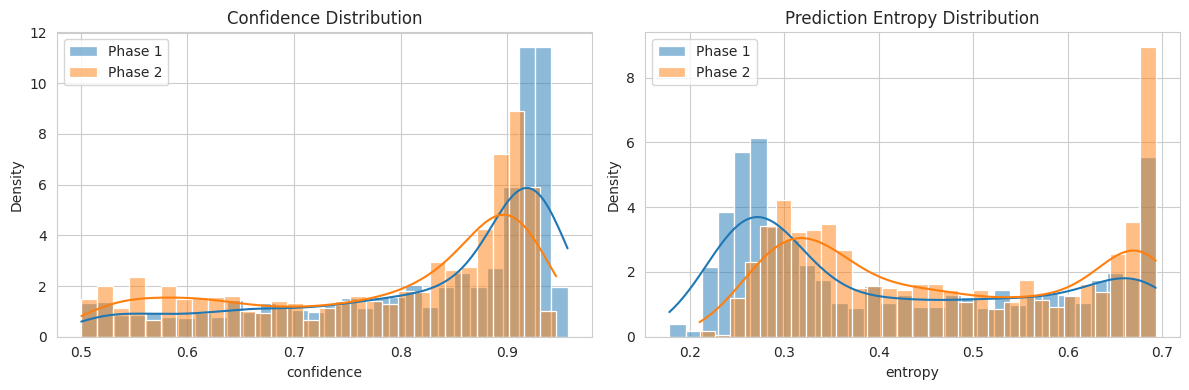

In [18]:
# Confidence / entropy comparison
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(d1["confidence"], bins=30, kde=True, ax=axes[0], color="tab:blue", label="Phase 1", stat="density", alpha=0.5)
sns.histplot(d2["confidence"], bins=30, kde=True, ax=axes[0], color="tab:orange", label="Phase 2", stat="density", alpha=0.5)
axes[0].set_title("Confidence Distribution")
axes[0].legend()

sns.histplot(d1["entropy"], bins=30, kde=True, ax=axes[1], color="tab:blue", label="Phase 1", stat="density", alpha=0.5)
sns.histplot(d2["entropy"], bins=30, kde=True, ax=axes[1], color="tab:orange", label="Phase 2", stat="density", alpha=0.5)
axes[1].set_title("Prediction Entropy Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

Prediction agreement rate: 79.10%


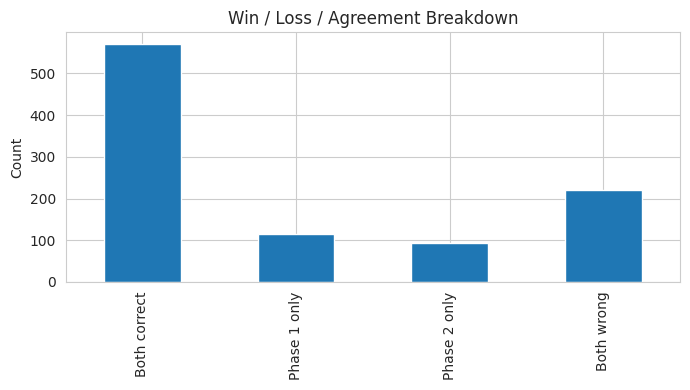

,count
Both correct,570
Phase 1 only,116
Phase 2 only,93
Both wrong,221


In [19]:
# Agreement / disagreement analysis
agree = (d1["pred_label"] == d2["pred_label"]).mean()
print(f"Prediction agreement rate: {agree:.2%}")

d1_ok = (d1["true_label"] == d1["pred_label"])
d2_ok = (d2["true_label"] == d2["pred_label"])

categories = pd.Series(np.select(
    [
        d1_ok & d2_ok,
        d1_ok & ~d2_ok,
        ~d1_ok & d2_ok,
    ],
    [
        "Both correct",
        "Phase 1 only",
        "Phase 2 only",
    ],
    default="Both wrong"
)).value_counts().reindex(["Both correct", "Phase 1 only", "Phase 2 only", "Both wrong"]).fillna(0)

plt.figure(figsize=(7,4))
categories.plot(kind="bar")
plt.title("Win / Loss / Agreement Breakdown")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

categories

In [20]:
# Robustness comparison
rob = r1.merge(r2, on="condition", suffixes=("_phase1", "_phase2"))
rob

,condition,accuracy_phase1,avg_confidence_phase1,entropy_phase1,accuracy_phase2,avg_confidence_phase2,entropy_phase2
0,clean,0.552,0.820552,0.417028,0.561,0.782599,0.471063
1,jpeg_q30,0.536,0.818917,0.419582,0.536,0.783276,0.471843
2,gaussian_noise,0.405,0.816095,0.425670,0.480,0.779319,0.477305
3,blur_r2,0.593,0.822469,0.416648,0.593,0.784213,0.468910
4,brightness_0.7,0.458,0.813992,0.426063,0.536,0.782914,0.474621


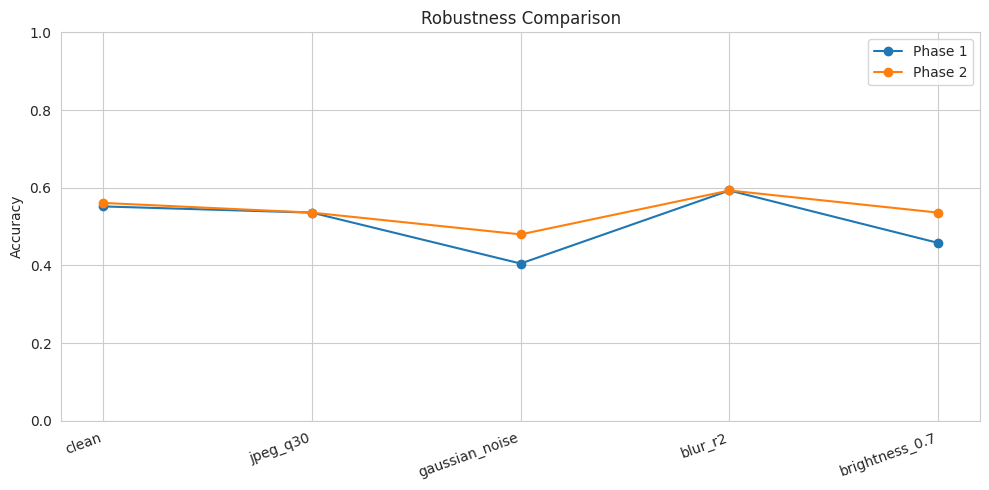

In [21]:
plt.figure(figsize=(10,5))
plt.plot(rob["condition"], rob["accuracy_phase1"], marker="o", label="Phase 1")
plt.plot(rob["condition"], rob["accuracy_phase2"], marker="o", label="Phase 2")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.title("Robustness Comparison")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# Save a comparison table
comp.to_csv("/content/model_comparison_table.csv", index=False)
print("Saved /content/model_comparison_table.csv")
comp

Saved /content/model_comparison_table.csv


,Model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,log_loss,ms_per_image,prediction_entropy,confidence_mean
0,Phase 1 / Distillation,0.686,0.687115,0.718750,0.631373,0.672234,0.735226,0.692923,2.690492,0.417028,0.820552
1,Phase 2 / Strong Regularization,0.663,0.664286,0.697039,0.600000,0.644889,0.740968,0.640654,3.429743,0.471063,0.782599
